Device: cuda
Mode:   FULL (production run)
Total candidates: 551,065
Columns: ['seriesuid', 'coordX', 'coordY', 'coordZ', 'class']

Class counts:
class
0    549714
1      1351
Name: count, dtype: int64

Negative:Positive ratio ≈ 407:1


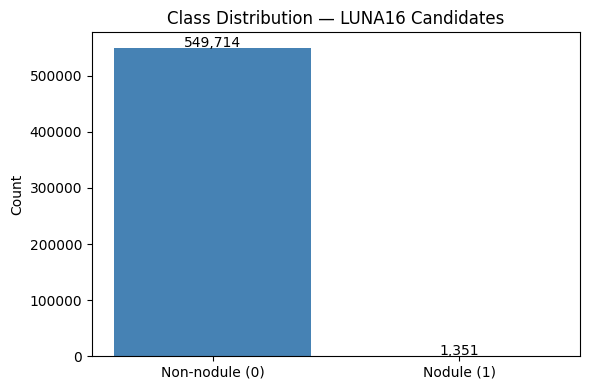

CT volumes found: 445
Candidates after filtering: 275,358

class       0    1
split             
test    54362  147
train  165568  433
val     54707  141
  train: 20/267 series done
  train: 40/267 series done
  train: 60/267 series done
  train: 80/267 series done
  train: 100/267 series done
  train: 120/267 series done
  train: 140/267 series done
  train: 160/267 series done
  train: 180/267 series done
  train: 200/267 series done
  train: 220/267 series done
  train: 240/267 series done
  train: 260/267 series done
train done — shape: (4652, 3, 64, 64) | positives: 416 | skipped: 111
  val: 20/89 series done
  val: 40/89 series done
  val: 60/89 series done
  val: 80/89 series done
val done — shape: (1481, 3, 64, 64) | positives: 128 | skipped: 70
  test: 20/89 series done
  test: 40/89 series done
  test: 60/89 series done
  test: 80/89 series done
test done — shape: (3048, 3, 64, 64) | positives: 144 | skipped: 39

Extraction complete.
Train — positives: 416 | negatives: 4236 |

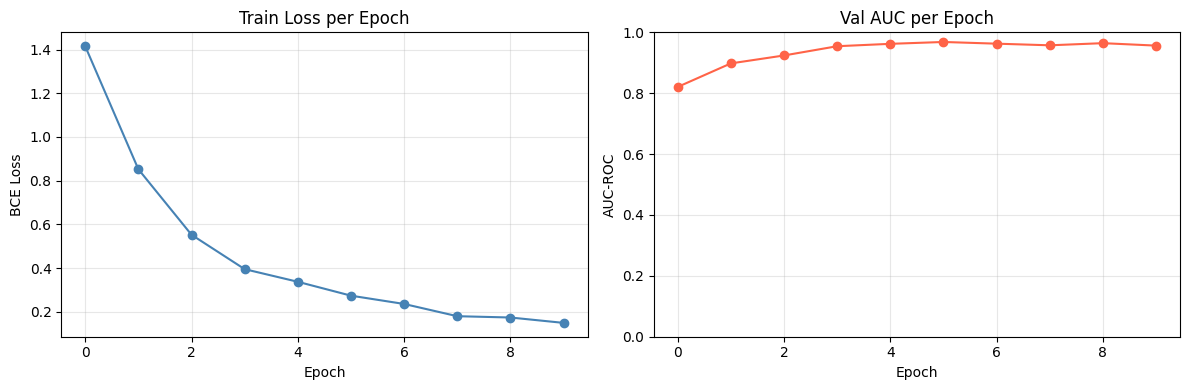

Test AUC-ROC: 0.9759
Threshold:   0.5101
Sensitivity: 0.9028  (of all nodules, 90.3% caught)
Specificity: 0.9363  (of all non-nodules, 93.6% dismissed)

Confusion matrix (rows = actual, cols = predicted):
  TN=2719  FP= 185
  FN=  14  TP= 130
Samples — TP:4  TN:4  FP:4  FN:4


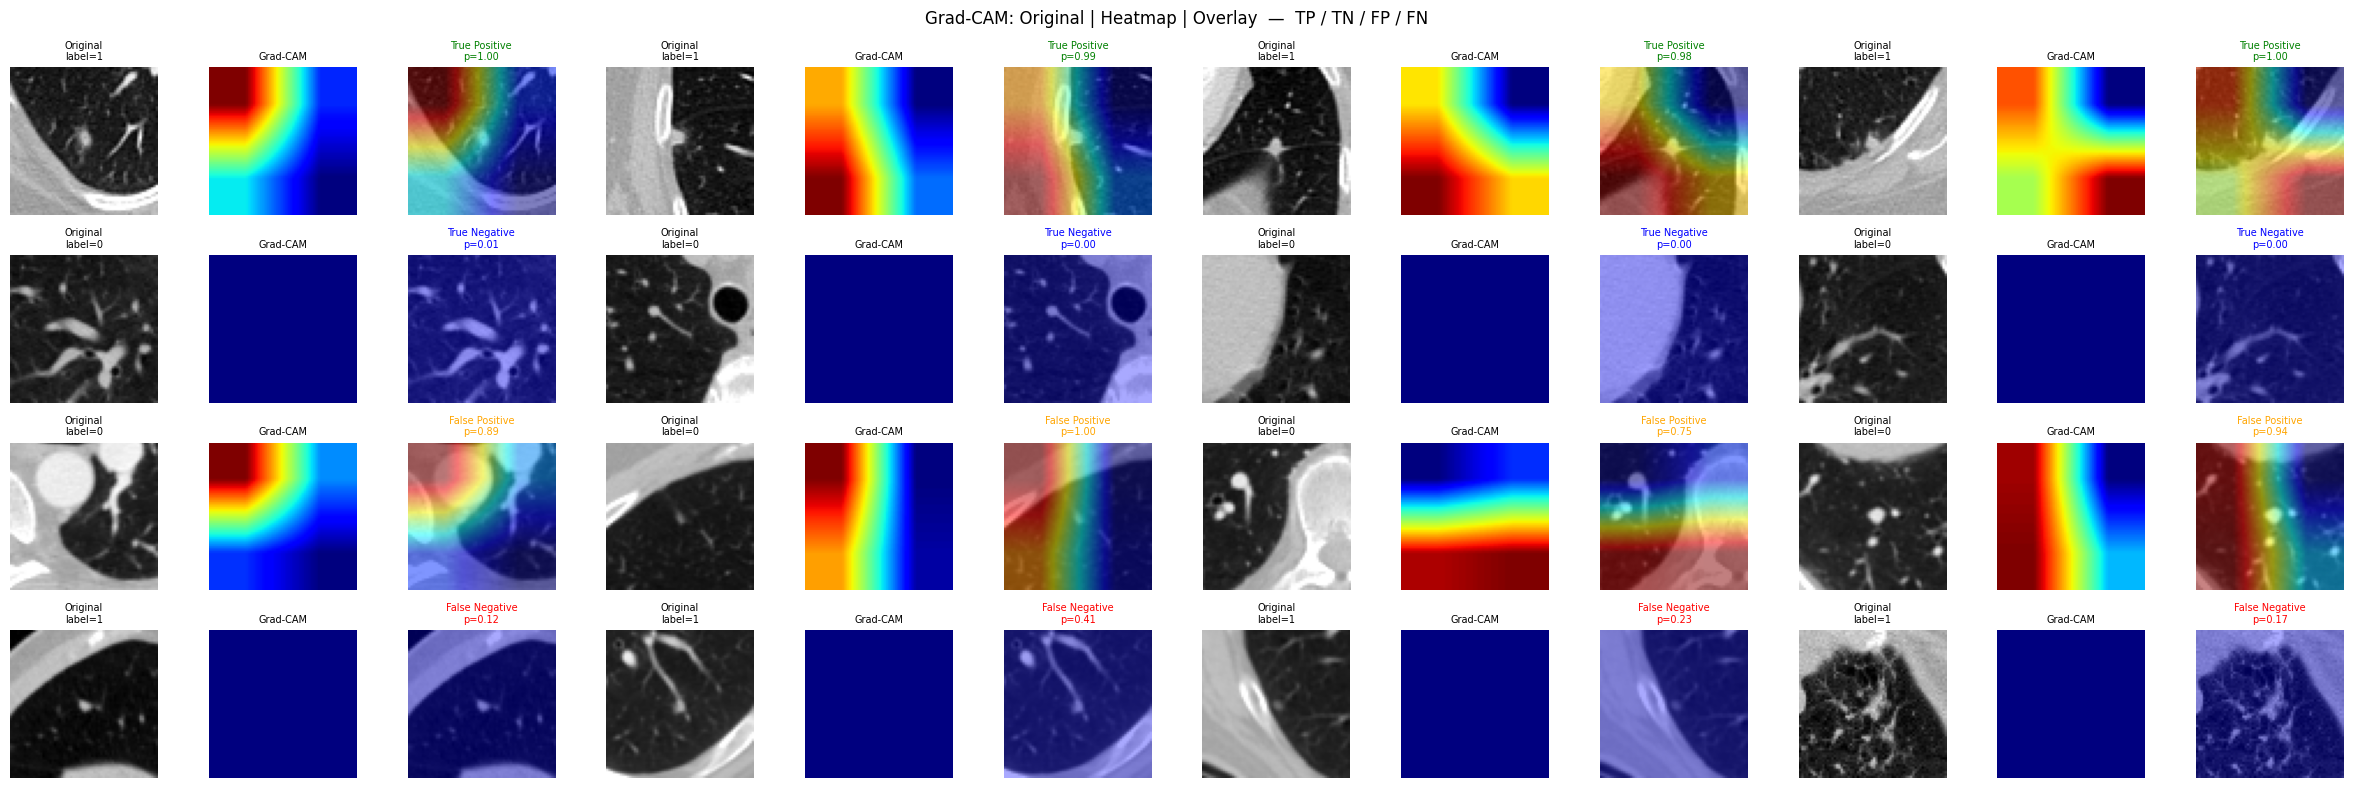

In [1]:
# =============================================================================
# LUNA16 Lung Nodule Classifier — Full Pipeline
# =============================================================================
# Task: given a small CT patch centred on a candidate location,
#       predict whether it contains a lung nodule (1) or not (0).
#
# Dataset: LUNA16 — 445 CT scans, 275,000+ labelled candidate locations
# Model:   ResNet-18 pretrained on ImageNet, fine-tuned on CT patches
#
# HOW TO USE:
#   - Copy each CELL into a separate Kaggle notebook cell
#   - Run top to bottom
#   - Set MINI_RUN = True for a quick 2-min pipeline test
#   - Set MINI_RUN = False for the real training run
# =============================================================================


# ── CELL 1: Imports ───────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import SimpleITK as sitk          # reads MHD/RAW CT files (LUNA16 format)
import subprocess
from pathlib import Path
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.models as models
import torchvision.transforms as transforms


# ── CELL 2: Configuration — change settings here ──────────────────────────────

MINI_RUN = False   # True = 2-min pipeline test | False = full training run

# Paths
BASE_DIR   = Path("/kaggle/input/datasets/avc0706/luna16")
SUBSETS    = [BASE_DIR / f"subset{i}" / f"subset{i}" for i in range(5)]
CANDIDATES = BASE_DIR / "candidates.csv"
PATCH_DIR  = Path("/kaggle/working/patches")
PATCH_DIR.mkdir(exist_ok=True)

# Patch settings
PATCH_SIZE = 64         # crop 64×64 pixels around each candidate
HU_MIN     = -1000      # Hounsfield Unit for air (black in CT)
HU_MAX     = 400        # Hounsfield Unit for soft tissue (white in CT)
                        # Clipping to this range removes irrelevant values like bone

# Class imbalance settings
# NEG_RATIO: how many negatives to extract per positive (keeps disk use manageable)
# POS_CAP:   max positives per split (only used in MINI_RUN mode)
NEG_RATIO = {"train": 10, "val": 10, "test": 20}
POS_CAP   = {"train": 50, "val": 15, "test": 15} if MINI_RUN else {"train": 9999, "val": 9999, "test": 9999}

# Training settings
BATCH_SIZE     = 32 if MINI_RUN else 64
MAX_EPOCHS     = 20
EARLY_PATIENCE = 4   # stop if val AUC doesn't improve for this many epochs

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Mode:   {'MINI (pipeline test)' if MINI_RUN else 'FULL (production run)'}")


# ── CELL 3: Load and explore candidates.csv ───────────────────────────────────
# Each row is one candidate location with:
#   seriesuid  — which CT scan it belongs to
#   coordX/Y/Z — location in millimetres (world space, not pixel indices)
#   class      — 1 = confirmed nodule, 0 = not a nodule

df = pd.read_csv(CANDIDATES)
print(f"Total candidates: {len(df):,}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nClass counts:\n{df['class'].value_counts()}")
print(f"\nNegative:Positive ratio ≈ {df['class'].value_counts()[0] / df['class'].value_counts()[1]:.0f}:1")


# ── CELL 4: Class distribution plot ───────────────────────────────────────────

counts = df["class"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
bars = plt.bar(["Non-nodule (0)", "Nodule (1)"], counts.values, color=["steelblue", "tomato"])
plt.title("Class Distribution — LUNA16 Candidates")
plt.ylabel("Count")
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 500,
             f"{val:,}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()


# ── CELL 5: Map seriesuids to file paths ──────────────────────────────────────
# Each CT scan is a .mhd file named by its seriesuid.
# We scan all subset folders and build a lookup: seriesuid → file path.

def build_uid_to_path(subset_dirs):
    uid_to_path = {}
    for subset_dir in subset_dirs:
        for mhd_file in Path(subset_dir).glob("*.mhd"):
            uid = mhd_file.stem        # filename without .mhd = seriesuid
            uid_to_path[uid] = mhd_file
    return uid_to_path

uid_to_path = build_uid_to_path(SUBSETS)
print(f"CT volumes found: {len(uid_to_path)}")


# ── CELL 6: Filter to available subsets and assign train/val/test splits ───────
# We only have subsets 0–4 so we drop candidates from subsets 5–9.
#
# Split is by subset — NOT random — because each subset has different patients.
# Random splitting would put the same patient in train and test (data leakage).
#
#   Subsets 0, 1, 2 → train
#   Subset 3        → val
#   Subset 4        → test

def get_subset_number(uid):
    path = uid_to_path.get(uid)
    if path is None:
        return None
    return int(path.parent.name.replace("subset", ""))

def assign_split(subset_num):
    if subset_num in [0, 1, 2]:
        return "train"
    elif subset_num == 3:
        return "val"
    else:
        return "test"

df["subset"] = df["seriesuid"].apply(get_subset_number)

df_filtered            = df.dropna(subset=["subset"]).copy()
df_filtered["subset"]  = df_filtered["subset"].astype(int)
df_filtered["split"]   = df_filtered["subset"].apply(assign_split)
df_filtered["mhd_path"] = df_filtered["seriesuid"].apply(lambda uid: str(uid_to_path[uid]))

print(f"Candidates after filtering: {len(df_filtered):,}")
print()
print(df_filtered.groupby(["split", "class"]).size().unstack(fill_value=0))


# ── CELL 7: Patch extraction helper functions ──────────────────────────────────

def resample_volume(sitk_image):
    """
    Resample the CT volume to 1×1×1 mm voxel spacing.

    Different CT scanners produce different slice thicknesses (e.g. 2mm or 3mm
    between axial slices). Resampling to 1mm isotropic means every voxel
    represents the same physical cube, making scans comparable across scanners.
    """
    original_spacing = sitk_image.GetSpacing()
    original_size    = sitk_image.GetSize()
    new_spacing      = [1.0, 1.0, 1.0]
    new_size = [
        int(round(original_size[i] * original_spacing[i] / new_spacing[i]))
        for i in range(3)
    ]
    resampler = sitk.ResampleImageFilter()
    resampler.SetOutputSpacing(new_spacing)
    resampler.SetSize(new_size)
    resampler.SetOutputDirection(sitk_image.GetDirection())
    resampler.SetOutputOrigin(sitk_image.GetOrigin())
    resampler.SetInterpolator(sitk.sitkLinear)
    resampler.SetDefaultPixelValue(-1000)   # fill any new voxels with air
    return resampler.Execute(sitk_image)


def world_to_voxel(world_coord, origin, spacing):
    """
    Convert world coordinates (mm) → voxel indices (pixel positions).

    candidates.csv stores coordinates in mm because that is scanner-independent.
    To index into the numpy array we need integer pixel positions.
    Formula: voxel_index = (world_mm - scan_origin_mm) / voxel_spacing_mm
    """
    return np.round((np.array(world_coord) - origin) / spacing).astype(int)


def extract_patch(volume, voxel_coord):
    """
    Extract a 3-channel 64×64 patch centred on the candidate coordinate.

    Why 3 slices (z-1, z, z+1)?
    A nodule spans multiple slices. Using 3 consecutive axial slices gives the
    model some 3D context without needing a full 3D network. The 3 slices map
    directly to the 3 colour channels ResNet expects (designed for RGB images).

    Returns shape (3, 64, 64) with values in [0, 1].
    Returns None if the candidate is too close to the scan boundary.
    """
    x, y, z = voxel_coord
    half     = PATCH_SIZE // 2
    z_dim, y_dim, x_dim = volume.shape

    # Skip candidates whose patch would extend outside the scan volume
    if (z - 1 < 0 or z + 1 >= z_dim or
            y - half < 0 or y + half > y_dim or
            x - half < 0 or x + half > x_dim):
        return None

    # Stack slices z-1, z, z+1 as 3 channels
    channels = [
        volume[z + dz, y - half : y + half, x - half : x + half]
        for dz in [-1, 0, 1]
    ]
    patch = np.stack(channels, axis=0).astype(np.float32)

    # HU windowing: clip to [−1000, 400] then rescale to [0, 1]
    # −1000 HU = air, ~0 HU = water, ~400 HU = soft tissue boundary
    # Bone (~1000 HU) is irrelevant for nodule detection so we clip it away
    patch = np.clip(patch, HU_MIN, HU_MAX)
    patch = (patch - HU_MIN) / (HU_MAX - HU_MIN)
    return patch


# ── CELL 8: Main extraction loop ──────────────────────────────────────────────
# Groups candidates by CT scan, loads each scan once, extracts all patches
# for that scan, then moves to the next. Saves to disk as .npy files so we
# never have to re-extract during training.
#
# Runtime: ~2 min (MINI_RUN=True) | ~15–25 min (MINI_RUN=False)

def extract_split(df_split, split_name):
    # Subsample positives (MINI only) and negatives to stay within disk limits
    all_pos   = df_split[df_split["class"] == 1]
    positives = all_pos.sample(n=min(POS_CAP[split_name], len(all_pos)), random_state=42)

    all_neg  = df_split[df_split["class"] == 0]
    n_neg    = min(len(all_neg), len(positives) * NEG_RATIO[split_name])
    negatives = all_neg.sample(n=n_neg, random_state=42)

    df_use  = pd.concat([positives, negatives]).reset_index(drop=True)
    grouped = df_use.groupby("seriesuid")

    all_patches, all_labels, skipped = [], [], 0

    for i, (uid, group) in enumerate(grouped):
        sitk_img = sitk.ReadImage(group["mhd_path"].iloc[0])
        sitk_img = resample_volume(sitk_img)
        origin   = np.array(sitk_img.GetOrigin())
        spacing  = np.array(sitk_img.GetSpacing())
        volume   = sitk.GetArrayFromImage(sitk_img)   # shape: (z, y, x)

        for _, row in group.iterrows():
            world = np.array([row["coordX"], row["coordY"], row["coordZ"]])
            voxel = world_to_voxel(world, origin, spacing)
            patch = extract_patch(volume, voxel)
            if patch is None:
                skipped += 1
                continue
            all_patches.append(patch)
            all_labels.append(int(row["class"]))

        if (i + 1) % 20 == 0:
            print(f"  {split_name}: {i + 1}/{len(grouped)} series done")

    patches_arr = np.stack(all_patches)
    labels_arr  = np.array(all_labels)

    np.save(PATCH_DIR / f"patches_{split_name}.npy", patches_arr)
    np.save(PATCH_DIR / f"labels_{split_name}.npy",  labels_arr)

    print(f"{split_name} done — shape: {patches_arr.shape} | "
          f"positives: {labels_arr.sum()} | skipped: {skipped}")


for split_name in ["train", "val", "test"]:
    extract_split(df_filtered[df_filtered["split"] == split_name], split_name)

print("\nExtraction complete.")


# ── CELL 9: Dataset class ─────────────────────────────────────────────────────
# PyTorch requires a Dataset object that returns one (patch, label) pair at a
# time. The DataLoader calls __getitem__ repeatedly to assemble batches.

class NoduleDataset(Dataset):
    def __init__(self, patches_path, labels_path, transform=None):
        self.patches   = np.load(patches_path)                     # (N, 3, 64, 64)
        self.labels    = np.load(labels_path).astype(np.float32)   # (N,)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        patch = torch.from_numpy(self.patches[idx])
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        if self.transform:
            patch = self.transform(patch)
        return patch, label


# ── CELL 10: Transforms, sampler, DataLoaders ─────────────────────────────────
# Augmentation is training-only — never applied at val or test.
# We avoid colour/brightness changes because HU values are physically calibrated
# and distorting them would corrupt the clinical meaning of the pixel values.

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
])

train_ds = NoduleDataset(PATCH_DIR / "patches_train.npy", PATCH_DIR / "labels_train.npy", transform=train_transform)
val_ds   = NoduleDataset(PATCH_DIR / "patches_val.npy",   PATCH_DIR / "labels_val.npy")
test_ds  = NoduleDataset(PATCH_DIR / "patches_test.npy",  PATCH_DIR / "labels_test.npy")

# WeightedRandomSampler gives positives a higher chance of being sampled.
# Without this, a batch of 64 from a 10:1 dataset would have ~6 positives —
# the model would rarely see nodules and learn to predict "not nodule" for everything.
train_labels = train_ds.labels
n_pos        = int(train_labels.sum())
n_neg        = len(train_labels) - n_pos
print(f"Train — positives: {n_pos} | negatives: {n_neg} | ratio: {n_neg/n_pos:.1f}:1")

sample_weights = np.where(train_labels == 1, 1.0 / n_pos, 4.0 / n_neg)
sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights).float(),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,    num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,    num_workers=2, pin_memory=True)

# Sanity check
patches_b, labels_b = next(iter(train_loader))
print(f"Batch shape:     {patches_b.shape}")
print(f"Batch pos count: {labels_b.sum().int().item()} / {len(labels_b)}")


# ── CELL 11: Model ────────────────────────────────────────────────────────────
# ResNet-18 pretrained on ImageNet. We keep all layers and only replace the
# final classification head to output a single number (nodule vs not).
#
# Why pretrained? Early layers already detect edges, shapes, and textures —
# features useful in CT too. Fine-tuning adapts these faster than training
# from scratch, especially with limited labelled medical data.
#
# Why ResNet-18 not ResNet-50? Patches are 64×64 — too small for a deeper
# network to benefit from. ResNet-18 is sufficient and trains much faster.

model = models.resnet18(weights="IMAGENET1K_V1")
model.fc = nn.Linear(512, 1)    # replace 1000-class head with single output
model = model.to(DEVICE)

# BCEWithLogitsLoss = binary cross-entropy with built-in sigmoid.
# pos_weight penalises missing a real nodule more heavily than a false alarm.
# This works alongside the sampler — both together are needed for this level of imbalance.
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(DEVICE)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer  = torch.optim.Adam(model.parameters(), lr=1e-4)
# Halve the learning rate if val AUC doesn't improve for 2 epochs
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
                 optimizer, mode="max", patience=2, factor=0.5)

print(f"Output layer: {model.fc}")
print(f"pos_weight:   {pos_weight.item():.2f}")
print(f"Parameters:   {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


# ── CELL 12: Training loop ────────────────────────────────────────────────────

best_auc       = 0.0
patience_count = 0
history        = {"train_loss": [], "val_auc": []}

for epoch in range(1, MAX_EPOCHS + 1):

    # --- Train phase ---
    model.train()
    running_loss = 0.0

    for patches, labels in train_loader:
        patches = patches.to(DEVICE)
        labels  = labels.to(DEVICE).unsqueeze(1)   # (B,) → (B,1) to match logit shape

        optimizer.zero_grad()
        logits = model(patches)         # forward pass — raw scores, not probabilities
        loss   = criterion(logits, labels)
        loss.backward()                 # compute gradients
        optimizer.step()               # update weights

        running_loss += loss.item() * len(labels)

    train_loss = running_loss / len(train_ds)

    # --- Validation phase ---
    model.eval()
    val_probs, val_targets = [], []

    with torch.no_grad():   # turn off gradients — not needed for evaluation
        for patches, labels in val_loader:
            patches = patches.to(DEVICE)
            logits  = model(patches)
            probs   = torch.sigmoid(logits).squeeze(1).cpu().numpy()
            val_probs.extend(probs)
            val_targets.extend(labels.numpy())

    # AUC-ROC: 0.5 = random, 1.0 = perfect.
    # Better than accuracy here because accuracy is misleading on imbalanced data
    # (a model predicting "not nodule" always would score 99%+ accuracy).
    val_auc = roc_auc_score(val_targets, val_probs)
    scheduler.step(val_auc)

    history["train_loss"].append(train_loss)
    history["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val AUC: {val_auc:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.2e}")

    # Save the best model weights and apply early stopping
    if val_auc > best_auc:
        best_auc       = val_auc
        patience_count = 0
        torch.save(model.state_dict(), "/kaggle/working/best_model.pth")
    else:
        patience_count += 1
        if patience_count >= EARLY_PATIENCE:
            print(f"\nEarly stopping — no improvement for {EARLY_PATIENCE} epochs.")
            break

print(f"\nBest Val AUC: {best_auc:.4f}")


# ── CELL 13: Training curves ──────────────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history["train_loss"], marker="o", color="steelblue")
ax1.set_title("Train Loss per Epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("BCE Loss")
ax1.grid(True, alpha=0.3)

ax2.plot(history["val_auc"], marker="o", color="tomato")
ax2.set_title("Val AUC per Epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("AUC-ROC")
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ── CELL 14: Test set evaluation ──────────────────────────────────────────────
# Load the best saved checkpoint and run it on the held-out test set.
# The test set was never seen during training or used to tune any decision.

model.load_state_dict(torch.load("/kaggle/working/best_model.pth"))
model.eval()

test_probs, test_targets = [], []

with torch.no_grad():
    for patches, labels in test_loader:
        patches = patches.to(DEVICE)
        logits  = model(patches)
        probs   = torch.sigmoid(logits).squeeze(1).cpu().numpy()
        test_probs.extend(probs)
        test_targets.extend(labels.numpy())

test_probs   = np.array(test_probs)
test_targets = np.array(test_targets)

test_auc = roc_auc_score(test_targets, test_probs)
print(f"Test AUC-ROC: {test_auc:.4f}")


# ── CELL 15: Sensitivity and Specificity ──────────────────────────────────────
# The model outputs a probability. We need a threshold to decide: nodule or not?
#
# In lung cancer screening, missing a real nodule (false negative) is far worse
# than a false alarm (false positive). So we choose the threshold where
# sensitivity (true positive rate) is at least 90%, then report specificity.
#
#   Sensitivity = of all real nodules, what fraction did we catch?
#   Specificity = of all non-nodules, what fraction did we correctly dismiss?

fpr, tpr, thresholds = roc_curve(test_targets, test_probs)

# Find the first threshold where sensitivity >= 90%
valid = [(tpr[i], 1 - fpr[i], thresholds[i])
         for i in range(len(tpr)) if tpr[i] >= 0.90]

if valid:
    sensitivity, specificity, threshold = valid[0]
else:
    # Fallback: use whichever threshold gets closest to 90%
    idx         = np.argmin(np.abs(tpr - 0.90))
    sensitivity = tpr[idx]
    specificity = 1 - fpr[idx]
    threshold   = thresholds[idx]

print(f"Threshold:   {threshold:.4f}")
print(f"Sensitivity: {sensitivity:.4f}  (of all nodules, {sensitivity*100:.1f}% caught)")
print(f"Specificity: {specificity:.4f}  (of all non-nodules, {specificity*100:.1f}% dismissed)")

preds = (test_probs >= threshold).astype(int)
cm    = confusion_matrix(test_targets, preds)
print(f"\nConfusion matrix (rows = actual, cols = predicted):")
print(f"  TN={cm[0,0]:4d}  FP={cm[0,1]:4d}")
print(f"  FN={cm[1,0]:4d}  TP={cm[1,1]:4d}")


# ── CELL 16: Grad-CAM visualisation ───────────────────────────────────────────
# Grad-CAM highlights which regions of each CT patch most influenced the
# model's prediction. It works by looking at which neurons in the last
# convolutional layer activated most strongly, then mapping that back onto
# the input image as a heatmap (red = most important, blue = least).
#
# We show 4 examples from each outcome category:
#   True Positive  (green)  — nodule, correctly detected
#   True Negative  (blue)   — not nodule, correctly dismissed
#   False Positive (orange) — not nodule, wrongly flagged
#   False Negative (red)    — nodule, missed
#
# The FP and FN cases are the most informative — they show where the model fails.

subprocess.run(["pip", "install", "grad-cam", "-q"])

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

cam = GradCAM(model=model, target_layers=[model.layer4[-1]])

results = list(zip(test_targets, test_probs, range(len(test_targets))))
tp = [(t, p, i) for t, p, i in results if t == 1 and p >= threshold][:4]
tn = [(t, p, i) for t, p, i in results if t == 0 and p <  threshold][:4]
fp = [(t, p, i) for t, p, i in results if t == 0 and p >= threshold][:4]
fn = [(t, p, i) for t, p, i in results if t == 1 and p <  threshold][:4]

print(f"Samples — TP:{len(tp)}  TN:{len(tn)}  FP:{len(fp)}  FN:{len(fn)}")

categories = [("True Positive",  tp, "green"),
              ("True Negative",  tn, "blue"),
              ("False Positive", fp, "orange"),
              ("False Negative", fn, "red")]

fig, axes = plt.subplots(4, 12, figsize=(24, 8))

for row_idx, (cat_name, samples, color) in enumerate(categories):
    for col_offset, (true_label, prob, idx) in enumerate(samples):
        patch     = torch.from_numpy(test_ds.patches[idx]).unsqueeze(0).to(DEVICE)
        heatmap   = cam(input_tensor=patch)[0]          # (64, 64) attention map

        centre    = test_ds.patches[idx][1]             # middle z-slice, shape (64,64)
        rgb       = np.stack([centre] * 3, axis=-1)     # convert to fake RGB for overlay
        overlay   = show_cam_on_image(rgb, heatmap, use_rgb=True)

        c = col_offset * 3   # starting column for this sample's 3 panels

        axes[row_idx, c].imshow(centre, cmap="gray", vmin=0, vmax=1)
        axes[row_idx, c].set_title(f"Original\nlabel={int(true_label)}", fontsize=7)
        axes[row_idx, c].axis("off")

        axes[row_idx, c + 1].imshow(heatmap, cmap="jet", vmin=0, vmax=1)
        axes[row_idx, c + 1].set_title("Grad-CAM", fontsize=7)
        axes[row_idx, c + 1].axis("off")

        axes[row_idx, c + 2].imshow(overlay)
        axes[row_idx, c + 2].set_title(f"{cat_name}\np={prob:.2f}", fontsize=7, color=color)
        axes[row_idx, c + 2].axis("off")

    # Hide unused columns if a category has fewer than 4 samples
    for col_offset in range(len(samples), 4):
        for c in range(3):
            axes[row_idx, col_offset * 3 + c].axis("off")

plt.suptitle("Grad-CAM: Original | Heatmap | Overlay  —  TP / TN / FP / FN", fontsize=12)
plt.tight_layout()
plt.show()